## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r "/content/drive/MyDrive/Aloe_Vera_Dataset" "/content/AloeDataset"


In [ ]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


## 2. Build the Good / Not_Good dataset from your existing folders

In [ ]:
SOURCE_DATASET = "/content/AloeDataset"
COLOUR_DATASET = "/content/ColourDataset"

GOOD_CLASSES = ["Young_Healthy", "Mature_Healthy"]
NOT_GOOD_CLASSES = ["Rot", "Discoloration", "Fungal_Infection", "Aloe_Rust", "Leaf_Spot"]

for split_name, classes in [("Good", GOOD_CLASSES), ("Not_Good", NOT_GOOD_CLASSES)]:
    dest = os.path.join(COLOUR_DATASET, split_name)
    os.makedirs(dest, exist_ok=True)
    for cls in classes:
        src_dir = os.path.join(SOURCE_DATASET, cls)
        if not os.path.isdir(src_dir):
            continue
        for fname in os.listdir(src_dir):
            src_file = os.path.join(src_dir, fname)
            dst_file = os.path.join(dest, f"{cls}_{fname}")
            if not os.path.exists(dst_file):
                shutil.copy(src_file, dst_file)

for folder in os.listdir(COLOUR_DATASET):
    n = len(os.listdir(os.path.join(COLOUR_DATASET, folder)))
    print(folder, ":", n, "images")


Good : 2000 images
Not_Good : 13584 images


In [ ]:
!pip install split-folders -q
import splitfolders

splitfolders.ratio(
    COLOUR_DATASET,
    output="/content/ColourSplit",
    seed=42,
    ratio=(0.7, 0.15, 0.15)   # train, val, test
)


Copying files: 15584 files [00:32, 474.49 files/s]


## 3. Load train / val / test sets

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ColourSplit/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ColourSplit/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ColourSplit/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False   # keep order so predictions line up with true labels
)

class_names = train_ds.class_names
print(class_names)  # ['Good', 'Not_Good']


Found 10908 files belonging to 2 classes.
Found 2337 files belonging to 2 classes.
Found 2339 files belonging to 2 classes.
['Good', 'Not_Good']


In [ ]:
labels = []
for _, batch_labels in train_ds:
    labels.extend(batch_labels.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(3.895714285714286), 1: np.float64(0.5736222128733698)}


In [ ]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


## 4. Build the model (MobileNetV2 transfer learning, binary output)

In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
outputs = Dense(1, activation="sigmoid")(x)  # 0 = Good, 1 = Not_Good

colour_model = Model(inputs, outputs)

colour_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

colour_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,385 (8.64 MB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 5. Train (frozen base, then fine-tune)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history = colour_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 309s 155ms/step - accuracy: 0.8882 - loss: 0.2302 - val_accuracy: 0.9760 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 2/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 273s 90ms/step - accuracy: 0.9497 - loss: 0.1276 - val_accuracy: 0.9807 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 3/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 243s 84ms/step - accuracy: 0.9576 - loss: 0.1095 - val_accuracy: 0.9872 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 4/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 252s 96ms/step - accuracy: 0.9580 - loss: 0.1072 - val_accuracy: 0.9859 - val_loss: 0.0383 - learning_rate: 0.0010
Epoch 5/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 296s 152ms/step - accuracy: 0.9554 - loss: 0.1165 - val_accuracy: 0.9880 - val_loss: 0.0373 - learning_rate: 0.0010
Epoch 6/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 248s 93ms/step - accuracy: 0.9558 - loss: 0.1197 - val_accuracy: 0.9829 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 7/20
682/682 ━━━━━━━━━━━━━━━━━━━━ 272s 153ms/step - accuracy: 

In [ ]:
# Fine-tune: fewer unfrozen layers (20 instead of 30), plus checkpointing to Drive.
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

colour_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

checkpoint_path = "/content/drive/MyDrive/Aloe_Colour_Model_checkpoint.keras"
fine_tune_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5),
    ModelCheckpoint(checkpoint_path, save_best_only=True, monitor="val_accuracy")
]

fine_tune_history = colour_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)


Epoch 1/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 220s 111ms/step - accuracy: 0.9512 - loss: 0.1697 - val_accuracy: 0.9867 - val_loss: 0.0452 - learning_rate: 1.0000e-05
Epoch 2/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 255s 99ms/step - accuracy: 0.9587 - loss: 0.1035 - val_accuracy: 0.9863 - val_loss: 0.0398 - learning_rate: 1.0000e-05
Epoch 3/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 226s 108ms/step - accuracy: 0.9657 - loss: 0.0851 - val_accuracy: 0.9897 - val_loss: 0.0332 - learning_rate: 1.0000e-05
Epoch 4/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 261s 102ms/step - accuracy: 0.9721 - loss: 0.0616 - val_accuracy: 0.9902 - val_loss: 0.0294 - learning_rate: 1.0000e-05
Epoch 5/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 263s 108ms/step - accuracy: 0.9704 - loss: 0.0732 - val_accuracy: 0.9906 - val_loss: 0.0284 - learning_rate: 1.0000e-05
Epoch 6/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 355s 161ms/step - accuracy: 0.9737 - loss: 0.0599 - val_accuracy: 0.9914 - val_loss: 0.0245 - learning_rate: 1.0000e-05
Epoch 7/10
682/682 ━━━━━━━━━━━━━━━━━━━━ 2

## 6. Training curves (accuracy & loss)

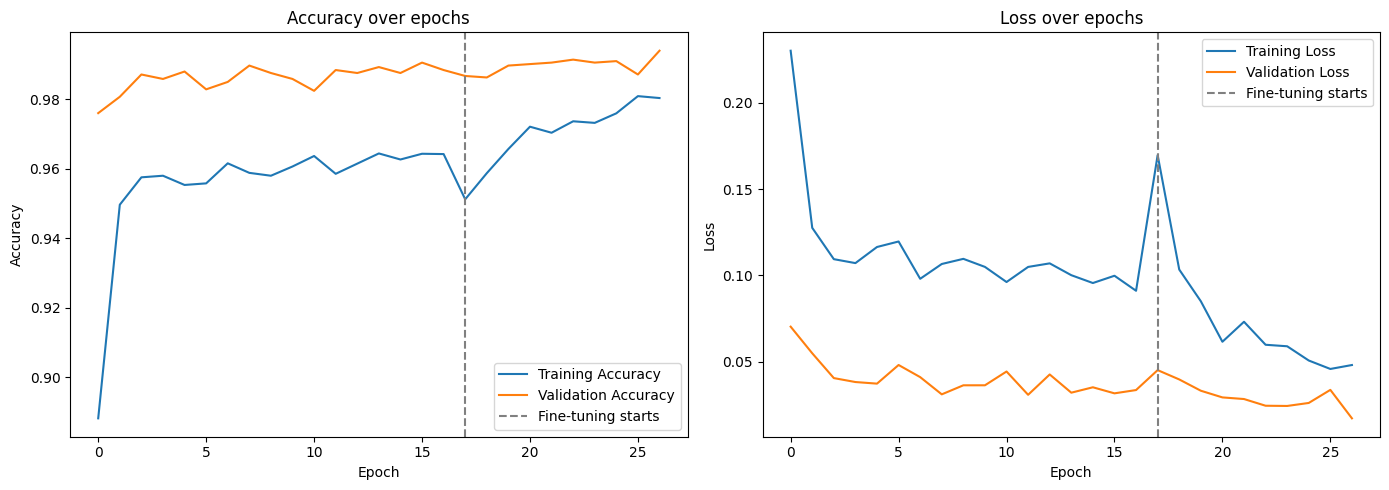

In [ ]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

fine_tune_start = len(history.history['accuracy'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(fine_tune_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(fine_tune_start, linestyle='--', color='gray', label='Fine-tuning starts')
plt.title('Loss over epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aloe_Colour_Model_training_curves.png', dpi=150)
plt.show()


## 7. Evaluate on the UNSEEN test set
This is the set the model never saw during training or fine-tuning, and was never used by any callback.

In [ ]:
test_loss, test_acc = colour_model.evaluate(test_ds)
print(f"Unseen test accuracy: {test_acc*100:.2f}%")
print(f"Unseen test loss: {test_loss:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 43s 292ms/step - accuracy: 0.9923 - loss: 0.0229
Unseen test accuracy: 99.23%
Unseen test loss: 0.0229


In [ ]:
test_probs = colour_model.predict(test_ds).flatten()
test_pred_labels = (test_probs > 0.5).astype(int)
test_true_labels = np.concatenate([y.numpy() for _, y in test_ds])

print(classification_report(test_true_labels, test_pred_labels, target_names=class_names))


147/147 ━━━━━━━━━━━━━━━━━━━━ 51s 338ms/step
              precision    recall  f1-score   support

        Good       0.97      0.97      0.97       300
    Not_Good       1.00      1.00      1.00      2039

    accuracy                           0.99      2339
   macro avg       0.98      0.98      0.98      2339
weighted avg       0.99      0.99      0.99      2339



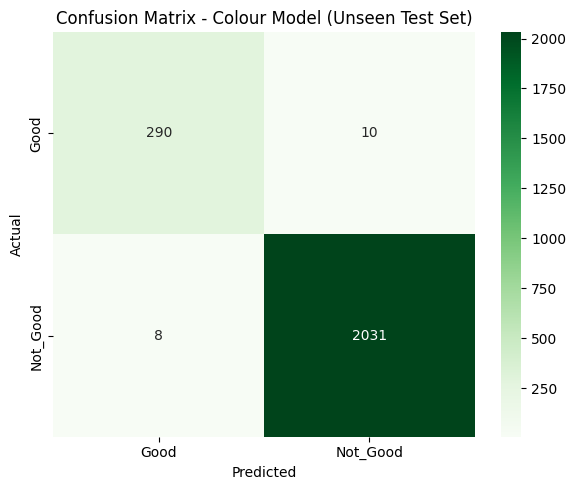

In [ ]:
cm = confusion_matrix(test_true_labels, test_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Colour Model (Unseen Test Set)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Aloe_Colour_Model_TEST_confusion_matrix.png', dpi=150)
plt.show()


## 8. Predict on a single image

In [ ]:
def predict_colour(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    prob_not_good = colour_model.predict(img_array, verbose=0)[0][0]
    verdict = "Not Good" if prob_not_good > 0.5 else "Good"
    confidence = prob_not_good * 100 if verdict == "Not Good" else (1 - prob_not_good) * 100

    print("=" * 50)
    print(f"Colour Prediction : {verdict}")
    print(f"Confidence        : {confidence:.2f}%")
    print("=" * 50)

    return verdict, round(float(confidence), 2)




## 9. Save the model

In [ ]:
colour_model.save("/content/Aloe_Colour_Model.keras")
!cp "/content/Aloe_Colour_Model.keras" "/content/drive/MyDrive/"
